# piano0909 `regular` -> `rubato`: overfit, then decode one step

Trains `configs/midi-translator-seq2seq2-rubato.yaml` on a handful of piano0909-100 pairs until it
memorizes them, takes the resulting checkpoint, and decodes ONE sliding-window step over a sample
the model was trained on -- then compares the decoded onsets against the ground-truth `rubato` arm.

**What this does and does not show.** Three limits are structural, not fixable by running longer:

1. **It is a plumbing check, not a measure of the model.** The decoded sample is a TRAINING sample
   and the model was driven to memorize it. A clean onset overlay says the feeder, the checkpoint
   and `SlidingTranslator` agree on the token axis -- it says nothing about generalization.
2. **One step is a prefix, not the piece.** `src_window` defaults to 640 tokens against files whose
   median is 877 lines, so a single step reads the opening only. The onset view covers that prefix.
3. **The source arm is synthetic.** piano0909's `regular/` is what a model WROTE (the corpus was
   generated rubato -> regular); `rubato/` is the real performance. This notebook trains the inverse
   direction, so the input carries whatever the generating checkpoint got wrong. See the config's
   own header block.

The overfit overrides deliberately depart from the committed config; each one is justified in the
cell that applies it.

In [1]:
import os, sys, json, time, subprocess, glob
from pathlib import Path
import yaml

REPO = Path('/home/camus/work/deep-starry')
os.chdir(REPO)
sys.path.insert(0, str(REPO))

CONFIG   = REPO / 'configs/midi-translator-seq2seq2-rubato.yaml'
CORPUS   = Path('/home/camus/data/midi/piano0909-100')
TRAINING = Path('/home/camus/data/training')

names = sorted(set(os.listdir(CORPUS / 'regular')) & set(os.listdir(CORPUS / 'rubato')))
print('config      :', CONFIG, CONFIG.is_file())
print('corpus      :', CORPUS, '-> %d shared pairs' % len(names))
print('training dir:', TRAINING, TRAINING.is_dir())

config      : /home/camus/work/deep-starry/configs/midi-translator-seq2seq2-rubato.yaml True
corpus      : /home/camus/data/midi/piano0909-100 -> 85 shared pairs
training dir: /home/camus/data/training True


In [2]:
# Verify every API this notebook calls BEFORE using it, so a rename surfaces here with a clear
# message instead of as a traceback five cells down.
import tools.midi.translateMidiseq2 as T

NEEDED = ['SlidingTranslator', 'load_model', 'resolve_checkpoint', 'resolve_tokenizer',
          'encode_lines', 'note_on_events', 'keyword_tokens']
missing = [n for n in NEEDED if not hasattr(T, n)]
for n in NEEDED:
    print(('  ok      ' if hasattr(T, n) else '  MISSING ') + n)
if missing:
    raise AttributeError('translateMidiseq2 has no %s -- the names below changed; grep the module '
                         'and update this notebook.' % ', '.join(missing))

from starry.midi.data.seq2seq2 import Seq2Seq2, _get_file
print('  ok      Seq2Seq2, _get_file')

/home/camus/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


  ok      SlidingTranslator
  ok      load_model
  ok      resolve_checkpoint
  ok      resolve_tokenizer
  ok      encode_lines
  ok      note_on_events
  ok      keyword_tokens
  ok      Seq2Seq2, _get_file


## 1. An overfit variant of the config

Six overrides. The first three are what makes overfitting possible at all: with `start_jitter` on or a
sampled `line_range`, the "same" sample is a DIFFERENT window every epoch, so there is no fixed target
to memorize. `splits` puts the same files on both sides on purpose -- val here measures memorization,
not generalization, and should not be read as a metric.

The fourth is subtler and was found the hard way. `SlidingTranslator.translate` hardcodes
`head=(step == 0)`, so its first window is always built in the HEAD form (`<bos>`, source from line 0).
A crop with `a > 0` gets no `<bos>` and opens its target with `<eom>` instead, so decoding it from a
head context asks the model to continue a sequence in a form it never saw for that sample -- it answers
with a stray leading elapse, and that constant offset drives the positional onset score to zero while
the token stream is still 95% identical. Under this corpus's deterministic crops only **16 of 85**
samples are head crops; `7..10/85` is a contiguous run of four of them.

In [3]:
N_SAMPLES = 4
base = yaml.safe_load(CONFIG.read_text())
ov   = json.loads(json.dumps(base))          # deep copy

# A UNIQUE run id per execution. `Configuration` only substitutes {date} (day granularity) and
# {filename}, so a same-day rerun resolves to the SAME directory -- and because the trainer resumes a
# directory it finds, the second run loads a checkpoint already at epoch 79, computes
# range(start_epoch=80, epoch=80), trains nothing, and exits leaving run 1's weights in place. Every
# cell downstream then scores a checkpoint trained on some earlier cell's samples. A timestamp is the
# whole fix.
STAMP = time.strftime('%Y%m%d-%H%M%S')
ov['id'] = 'midi/%s-rubato-overfit' % STAMP
# Corpus indices 7..10 -- four HEAD crops (a == 0), the only kind SlidingTranslator's step 0 can be
# asked to reproduce. Verified below, not assumed. Same files on both sides; no leading '*', so
# neither side shuffles.
SPLIT = '7..10/85'
ov['data']['splits']     = '%s:%s' % (SPLIT, SPLIT)
ov['data']['batch_size'] = N_SAMPLES

a = ov['data']['args']
a['start_jitter'] = 0        # a moving start is a moving target
a['random_crop']  = False    # one fixed crop per sample, every epoch
a['line_range']   = 256      # scalar == a FIXED cap, so the window does not vary either
ov['data'].pop('args_variant', None)   # random_crop is now set for both segments directly

ov['trainer']['epoch']      = 80
ov['trainer']['epoch_size'] = N_SAMPLES * 16      # 16 steps an epoch
# 2000 warmup steps is ~20x this whole run -- lr would never leave the ramp.
ov['optim']['scheduler']['args']['n_warmup_steps'] = 50

nw  = ov['optim']['scheduler']['args']['n_warmup_steps']
d   = ov['model']['args']['d_model']
mul = ov['optim']['scheduler']['args']['lr_mul']
print('peak lr = %.3e at step %d (committed config: 1.40e-04 at 2000)' % (mul * d ** -0.5 * nw ** -0.5, nw))
print('steps    = %d epochs x %d = %d' % (ov['trainer']['epoch'],
      ov['trainer']['epoch_size'] // ov['data']['batch_size'],
      ov['trainer']['epoch'] * ov['trainer']['epoch_size'] // ov['data']['batch_size']))

# .local.yaml is gitignored, which is what we want for a throwaway probe.
OVERFIT = REPO / 'configs/midi-translator-seq2seq2-rubato-overfit.local.yaml'
OVERFIT.write_text(yaml.safe_dump(ov, sort_keys=False, default_flow_style=False))
print('wrote', OVERFIT)

peak lr = 8.839e-04 at step 50 (committed config: 1.40e-04 at 2000)
steps    = 80 epochs x 16 = 1280
wrote /home/camus/work/deep-starry/configs/midi-translator-seq2seq2-rubato-overfit.local.yaml


## 2. Train

`train.py` is the SINGLE-PROCESS trainer (`starry/utils/trainer.py`, `epoch` singular) -- the
committed config targets it deliberately, since this workstation has one 3090. Expect the initial
loss near `ln(582) = 6.37` and, if the overfit takes, a train loss well under 0.1 by the end.

In [4]:
env = dict(os.environ, PYTHONPATH=str(REPO))
proc = subprocess.Popen([sys.executable, 'train.py', str(OVERFIT)], cwd=str(REPO), env=env,
                        stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True, bufsize=1)
log = []
for line in proc.stdout:
    log.append(line)
    # Keep the cell readable: epoch headers and the loss lines only, not the progress bars.
    if ('Epoch' in line or 'loss:' in line or 'Error' in line or 'Traceback' in line):
        print(line.rstrip()[:160])
proc.wait()
print('\nexit code', proc.returncode)

20260917 17:23:22	INFO	[Epoch 0]


20260917 17:23:22	INFO	  - (Validation) loss:  6.4271e+00, acc: 0.0008, err: 0.9992, lr: 1.0000e-03, elapse: 0.01 min


20260917 17:23:26	INFO	  - (Training)   loss:  5.6308e+00, acc: 0.1032, err: 0.8968, grad_norm: 3.7764, lr: 2.8284e-04, elapse: 0.07 min
20260917 17:23:26	INFO	[Epoch 1]
20260917 17:23:26	INFO	  - (Validation) loss:  5.0129e+00, acc: 0.1420, err: 0.8580, lr: 2.8284e-04, elapse: 0.00 min


20260917 17:23:30	INFO	  - (Training)   loss:  4.2628e+00, acc: 0.2014, err: 0.7986, grad_norm: 2.5732, lr: 5.6569e-04, elapse: 0.07 min
20260917 17:23:31	INFO	[Epoch 2]


20260917 17:23:31	INFO	  - (Validation) loss:  3.4916e+00, acc: 0.2612, err: 0.7388, lr: 5.6569e-04, elapse: 0.00 min


...

20260917 17:30:11	INFO	  - (Validation) loss:  9.4219e-05, acc: 1.0000, err: 0.0000, lr: 1.7692e-04, elapse: 0.00 min


20260917 17:30:15	INFO	  - (Training)   loss:  1.4302e-03, acc: 0.9996, err: 0.0004, grad_norm: 0.3091, lr: 1.7579e-04, elapse: 0.07 min
20260917 17:30:15	INFO	[Epoch 79]


20260917 17:30:15	INFO	  - (Validation) loss:  8.7216e-05, acc: 1.0000, err: 0.0000, lr: 1.7579e-04, elapse: 0.00 min


20260917 17:30:19	INFO	  - (Training)   loss:  1.6088e-03, acc: 0.9997, err: 0.0003, grad_norm: 0.2370, lr: 1.7469e-04, elapse: 0.07 min



exit code 0


## 3. Take the weights

`resolve_checkpoint` prefers `config['best']` (the name `save_mode: best` records, having pruned the
rest), then `best.chkpt`, then `latest.chkpt`. `load_model` builds the BARE translator from the run's
own `.state.yaml` -- no `Loss` postfix, since the checkpoint holds only `deducer`'s state_dict.

The tokenizer comes from the RUN directory, not the checkout: the vocabulary is positional, so the
run's pinned copy is what the checkpoint's embedding rows mean.

In [5]:
import torch
from starry.utils.config import Configuration

# THIS execution's run, by its stamp -- not the newest match, which on a same-day rerun can be an
# older run's directory and would quietly score the wrong checkpoint.
RUN = str(TRAINING / 'midi' / ('%s-rubato-overfit' % STAMP))
if not os.path.isdir(RUN):
    raise FileNotFoundError('%s does not exist -- did the training cell succeed?' % RUN)
print('run       :', RUN)

cfg  = Configuration.createOrLoad(RUN, volatile=True)
ckpt = T.resolve_checkpoint(RUN, cfg)
print('checkpoint:', os.path.basename(ckpt))

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
cfg, model = T.load_model(RUN, ckpt, DEVICE)
tk, vocab_path = T.resolve_tokenizer(RUN, cfg)
print('vocab     :', vocab_path)
print('device    :', DEVICE)
print('pos_style :', cfg['data.args'].get('pos_style'))

run       : /home/camus/data/training/midi/20260917-172316-rubato-overfit
checkpoint: model_79_loss_8.722e-05.chkpt


[load] model_79_loss_8.722e-05.chkpt (epoch 78)
vocab     : /home/camus/data/training/midi/20260917-172316-rubato-overfit/midiseq2Vocab.yaml
device    : cuda
pos_style : sep


## 4. Pick a training sample -- and the crop it was actually trained on

**This is the step that makes or breaks the comparison.** `random_crop: False` pins ONE crop per
sample for every epoch, and the feeder chooses it, not us. Decoding from source line 0 when the crop
starts at bar 14 asks the model for a window it never saw; comparing against target line 0 measures
nothing.

Two traps live in this cell, both of which turn a perfect overfit into an apparent total miss:

1. **`describe(i)` takes a CORPUS index, while `__getitem__` maps through `self.indices`.** Handing it
   a split position returns some other sample's crop, silently. Iterate `ds.indices`.
2. **The ground truth is the crop's own `ids`, not a re-encoding of its target lines.** `_encode`
   applies the crop's alignment and a position base; re-encoding `target_range` from the file reproduces
   neither, and the resulting stream differs from what the model was actually trained to emit.

In [6]:
import starry.utils.env            # loads .env.local -> DATA_DIR, as train.py sees it
from starry.utils.dataset_factory import loadDataset

train_loader, _ = loadDataset(cfg, data_dir=os.environ['DATA_DIR'], device='cpu')
ds = getattr(train_loader, 'dataset', train_loader)
# ds.names is the WHOLE corpus; ds.indices holds the corpus positions this split serves.
print('split serves %d samples at corpus indices %s' % (len(ds), ds.indices))

cases = {gi: ds.describe(gi) for gi in ds.indices}
for gi, c in cases.items():
    print('  corpus %2d  %-26s a=%2d z=%2d head=%-5s tail=%-5s target_half=%4d'
          % (gi, c['name'], c['a'], c['z'], c['head'], c['tail'], len(c['ids']) - c['sep'] - 1))

non_head = [gi for gi, c in cases.items() if not c['head']]
if non_head:
    print('\nWARNING: corpus indices %s are NOT head crops. SlidingTranslator builds step 0 in the '
          'head form, so their decode will carry a constant offset and the positional score will '
          'read near zero even on a perfect overfit.' % non_head)

INDEX = ds.indices[0]
case   = cases[INDEX]
SAMPLE = case['name']
S0, S1 = case['source_range']
SEP    = case['sep']
TARGET_IDS = case['ids'][SEP + 1:]      # THE training target, exactly as supervised

src_all  = (CORPUS / 'regular' / SAMPLE).read_text().splitlines()
src_crop = src_all[S0:S1]               # what the model read during training

print('\nchosen: %s  (corpus index %d)' % (SAMPLE, INDEX))
print('  source_range   lines %d..%d of %d' % (S0, S1, len(src_all)))
print('  target ids     %d tokens' % len(TARGET_IDS))
print('  source bars    %s' % [n for _, n in case['source_measures']])
print('  target bars    %s' % [n for _, n in case['target_measures']])

split serves 4 samples at corpus indices [7, 8, 9, 10]
  corpus  7  002f0a369d.midiseq2.txt    a= 0 z= 5 head=True  tail=True  target_half= 720
  corpus  8  0035a69e52.midiseq2.txt    a= 0 z= 6 head=True  tail=False target_half= 765
  corpus  9  00371810f5.midiseq2.txt    a= 0 z= 9 head=True  tail=False target_half= 812
  corpus 10  003746d3d1.midiseq2.txt    a= 0 z= 5 head=True  tail=True  target_half= 295

chosen: 002f0a369d.midiseq2.txt  (corpus index 7)
  source_range   lines 0..133 of 133
  target ids     720 tokens
  source bars    [1, 2, 3, 4, 5]
  target bars    [1, 2, 3, 4, 5]


## 5. Two checks, in order

**Teacher-forced first.** Feeding the crop's own `ids` back through the model and scoring the target
half answers "did the overfit take?" with no sliding-window machinery in the way. If this is not ~1.0,
nothing downstream is interpretable.

**Then free-run.** `max_steps=1` stops after the first window. The source handed in is `src_crop`, so
the translator reads the same lines the crop did. `pos_style` and `source_eom` are read off the RUN's
config rather than restated, so the translator cannot drift from what the checkpoint trained under;
`temperature=0.0` makes it greedy and reproducible.

In [7]:
# Teacher-forced: the crop's own ids, scored on the target half only.
import torch
ids_t = torch.tensor([case['ids']], device=DEVICE)
with torch.no_grad():
    logits = model(ids_t)
pred = logits[0].argmax(-1)[:-1].tolist()
gold = case['ids'][1:]
pairs = [(p, g) for i, (p, g) in enumerate(zip(pred, gold)) if i >= SEP]
tf_acc = sum(p == g for p, g in pairs) / len(pairs)
print('teacher-forced target-half accuracy: %.4f over %d tokens' % (tf_acc, len(pairs)))
if tf_acc < 0.99:
    print('  WARNING: the overfit did not take -- read nothing into the free-run decode below.')

teacher-forced target-half accuracy: 1.0000 over 720 tokens


In [8]:
args = cfg['data.args'] or {}
translator = T.SlidingTranslator(
    model, tk,
    pos_style=args.get('pos_style', 'sep'),
    source_eom=bool(args.get('source_eom', False)),
    max_token=int(args.get('max_tokens') or 2048),
    device=DEVICE,
    temperature=0.0,
)
print('src_window %d  max_token %d  prime %s' % (translator.src_window, translator.max_token, translator.prime))

# src_crop, NOT the whole file: the crop's own source lines are the only input this checkpoint has
# ever seen for this sample. With a head crop (a == 0) these start at line 0, so the translator's
# head-form step 0 matches how the target was assembled.
out_ids, stats = translator.translate(src_crop, verbose=True, max_steps=1)
print('\ndecoded %d tokens in 1 step  (training target: %d tokens)' % (len(out_ids), len(TARGET_IDS)))
print('consumed %s of %d crop source lines' % (stats.get('consumed_lines'), len(src_crop)))

src_window 640  max_token 2048  prime True


  step    0  src[0:26]   308 tok  prime     0  gen   718  rolled   94 tok /   8 onsets  out     718  T  1029

decoded 718 tokens in 1 step  (training target: 720 tokens)
consumed 26 of 133 crop source lines


In [9]:
# Token view, and the token-level agreement with the training target. Built from the tokenizer's own
# id->token inverse rather than a text renderer, so it cannot disagree with what the model emitted.
#
# The target half is compared with its WRAPPERS STRIPPED. `_assemble` puts <bos> at the front of a head
# crop's target and <eos> at the end of every crop's, but `translate` emits neither -- <eos> is a stop
# signal it consumes, and <bos> belongs to the prefix it builds itself. Leaving them in reports
# "identical leading tokens: 0" and two spurious edits on a byte-perfect reproduction.
import collections, difflib

inv  = {v: k for k, v in tk.id_by_token.items()}
bos, eos = tk.id_by_token.get('<bos>'), tk.id_by_token.get('<eos>')

core = list(TARGET_IDS)
stripped = []
if core and core[0] == bos:
    stripped.append('<bos>'); core = core[1:]
if core and core[-1] == eos:
    stripped.append('<eos>'); core = core[:-1]

toks = [inv.get(i, '<?%d>' % i) for i in out_ids]
gold = [inv.get(i, '<?%d>' % i) for i in core]
print('target wrappers stripped: %s  -> %d content tokens' % (stripped or 'none', len(core)))
print('\ntarget  first 24:\n ', ' '.join(gold[:24]))
print('decoded first 24:\n ', ' '.join(toks[:24]))

lead = 0
for x, y in zip(core, out_ids):
    if x != y:
        break
    lead += 1
sm = difflib.SequenceMatcher(a=core, b=out_ids, autojunk=False)
print('\nidentical leading tokens : %d of %d' % (lead, len(core)))
print('token-level similarity   : %.4f' % sm.ratio())
print('longest identical run    : %d of %d' % (
    max((b.size for b in sm.get_matching_blocks()), default=0), len(core)))
ops = [o for o in sm.get_opcodes() if o[0] != 'equal']
print('token edit ops           : %d' % len(ops))
for tag, i1, i2, j1, j2 in ops[:6]:
    print('  %-8s target[%d:%d]=%s -> decoded[%d:%d]=%s'
          % (tag, i1, i2, gold[i1:i2][:6], j1, j2, toks[j1:j2][:6]))
if not ops:
    print('  (none -- the free run reproduced the training target token for token)')

target wrappers stripped: ['<bos>', '<eos>']  -> 718 content tokens

target  first 24:
  ticks_per_beat 1 e 0 format_type 1 set_tempo 7 a 1 2 0 time_signature 4 _ 4 _ 1 8 _ 8 control_change #40 E010
decoded first 24:
  ticks_per_beat 1 e 0 format_type 1 set_tempo 7 a 1 2 0 time_signature 4 _ 4 _ 1 8 _ 8 control_change #40 E010

identical leading tokens : 718 of 718
token-level similarity   : 1.0000
longest identical run    : 718 of 718
token edit ops           : 0
  (none -- the free run reproduced the training target token for token)


## 6. Onset comparison against ground truth

Onsets come from the module's own `note_on_events`, NOT from a hand-rolled elapse decoder: midiseq2's
E-run is a plain hex sum whose mid nibble-byte is already pre-shifted, so an independent parser that
applies `<< 4` inflates every delta 16x and does it silently. Using the tool's helper keeps this view
on the same time axis the translator itself used.

Ground truth is `TARGET_IDS` -- the crop's supervised target tokens. Both series are decoded by the
same helper from the same kind of stream, so they share an onset origin, which is the only way the
overlay means anything.

In [10]:
kw = T.keyword_tokens(tk)

ev_gt,  _, _ = T.note_on_events(core, tk, kw)
ev_dec, _, _ = T.note_on_events(out_ids,    tk, kw)

print('ground truth events (training target):', len(ev_gt))
print('decoded events                       :', len(ev_dec))
if ev_dec:
    print('event keys                           :', sorted(ev_dec[0]))

PITCH = next((k for k in ('pitch', 'note', 'key', 'value') if ev_dec and k in ev_dec[0]), None)
print('pitch key                            :', PITCH or '(none found -- onset-only view below)')
print('\ntruth   first 12 onsets ', [e['onset'] for e in ev_gt[:12]])
print('decoded first 12 onsets ', [e['onset'] for e in ev_dec[:12]])

ground truth events (training target): 80
decoded events                       : 80
event keys                           : ['channel', 'onset', 'order', 'pitch', 'pitch_index']
pitch key                            : pitch

truth   first 12 onsets  [30, 160, 263, 386, 523, 551, 822, 946, 1053, 1180, 1331, 1336]
decoded first 12 onsets  [30, 160, 263, 386, 523, 551, 822, 946, 1053, 1180, 1331, 1336]


decoded span: onset 0..8173   ground-truth events in that span: 80


figure written to /home/camus/data/training/midi/20260917-172316-rubato-overfit/onset_compare_002f0a369d.png


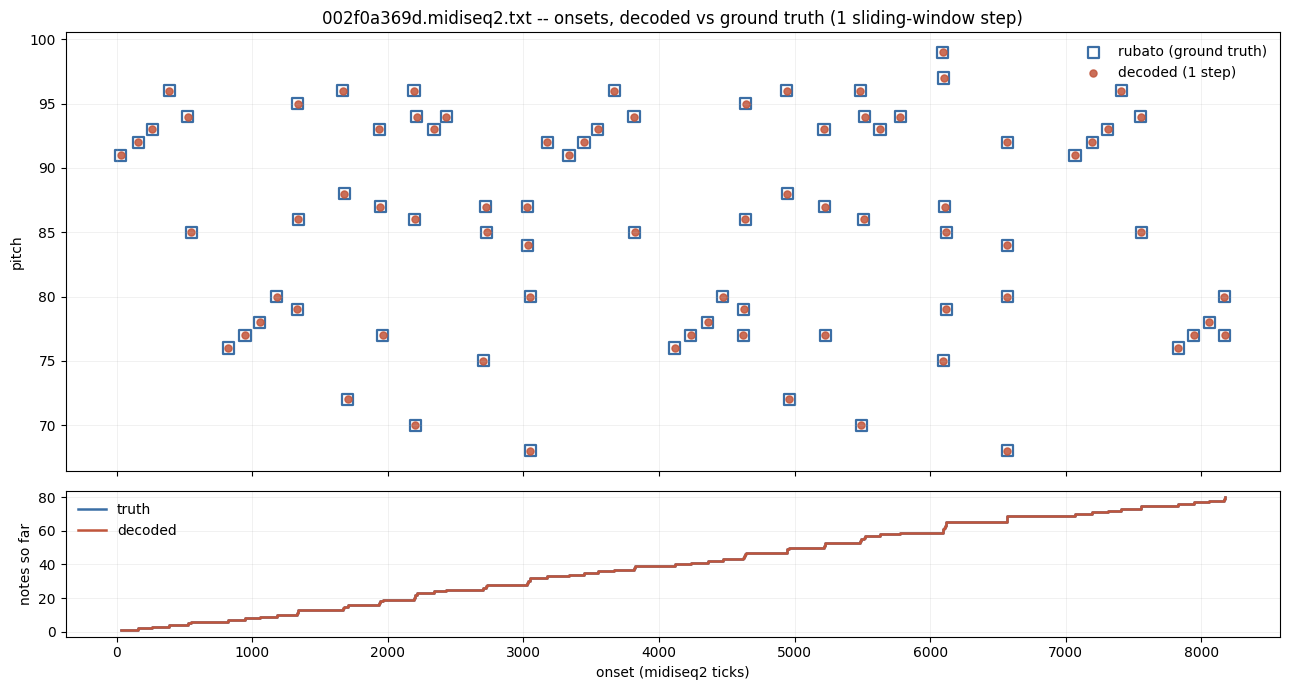

In [11]:
%matplotlib inline
import matplotlib.pyplot as plt

span = max((e['onset'] for e in ev_dec), default=0)
gt_in = [e for e in ev_gt if e['onset'] <= span] if span else []
print('decoded span: onset 0..%s   ground-truth events in that span: %d' % (span, len(gt_in)))

fig, ax = plt.subplots(2, 1, figsize=(13, 7), sharex=True,
                       gridspec_kw=dict(height_ratios=[3, 1]))

if PITCH:
    ax[0].scatter([e['onset'] for e in gt_in], [e[PITCH] for e in gt_in],
                  s=64, marker='s', facecolors='none', edgecolors='#3b6ea5',
                  linewidths=1.6, label='rubato (ground truth)')
    ax[0].scatter([e['onset'] for e in ev_dec], [e[PITCH] for e in ev_dec],
                  s=26, marker='o', color='#c1553b', alpha=0.85, label='decoded (1 step)')
    ax[0].set_ylabel('pitch')
else:
    ax[0].eventplot([[e['onset'] for e in gt_in], [e['onset'] for e in ev_dec]],
                    colors=['#3b6ea5', '#c1553b'], lineoffsets=[1, 0], linelengths=0.8)
    ax[0].set_yticks([1, 0]); ax[0].set_yticklabels(['truth', 'decoded'])

ax[0].set_title('%s -- onsets, decoded vs ground truth (1 sliding-window step)' % SAMPLE)
ax[0].legend(loc='upper right', frameon=False)
ax[0].grid(alpha=0.25, linewidth=0.5)

# Cumulative note count on the shared axis: divergence in DENSITY is what a per-note view hides,
# and an over-generating run reads as a steeper line rather than as a wrong note.
for evs, colour, label in ((gt_in, '#3b6ea5', 'truth'), (ev_dec, '#c1553b', 'decoded')):
    xs = sorted(e['onset'] for e in evs)
    ax[1].step(xs, range(1, len(xs) + 1), where='post', color=colour, label=label, linewidth=1.8)
ax[1].set_xlabel('onset (midiseq2 ticks)'); ax[1].set_ylabel('notes so far')
ax[1].legend(loc='upper left', frameon=False); ax[1].grid(alpha=0.25, linewidth=0.5)

plt.tight_layout()
FIG = os.path.join(RUN, 'onset_compare_%s.png' % SAMPLE.split('.')[0])
fig.savefig(FIG, dpi=110, bbox_inches='tight')
print('figure written to', FIG)
plt.show()

In [12]:
# Numbers behind the picture. Two kinds, and they answer different questions.
#
# POSITIONAL (exact onset+pitch) is brittle by construction: one dropped or added note early shifts
# every later onset by a few ticks, so a stream that is otherwise identical scores near zero. Density
# is the guard in the other direction -- a run that pours notes onto a few positions scores well
# per-note while being badly wrong.
#
# SHIFT-TOLERANT (edit distance over the pitch sequence, and over inter-onset intervals) is what
# actually tells you whether the model reproduced the target, since neither is disturbed by a
# constant offset.
import difflib

span = max((e['onset'] for e in ev_dec), default=0)
gt_in = [e for e in ev_gt if e['onset'] <= span] if span else []

if ev_dec and gt_in:
    print('notes  decoded %d  truth-in-span %d   density %.3f  (1.0 = matched)'
          % (len(ev_dec), len(gt_in), len(ev_dec) / len(gt_in)))
    gset, dset = {e['onset'] for e in gt_in}, {e['onset'] for e in ev_dec}
    print('distinct onsets  decoded %d  truth %d   shared %d' % (len(dset), len(gset), len(gset & dset)))

    if PITCH:
        gp = collections.Counter((e['onset'], e[PITCH]) for e in gt_in)
        dp = collections.Counter((e['onset'], e[PITCH]) for e in ev_dec)
        exact = sum((gp & dp).values())
        print('exact (onset, pitch):  %d of %d  (%.1f%%)   <- positional, brittle'
              % (exact, len(gt_in), 100.0 * exact / len(gt_in)))

        sm = difflib.SequenceMatcher(a=[e[PITCH] for e in gt_in],
                                     b=[e[PITCH] for e in ev_dec], autojunk=False)
        print('pitch-sequence similarity: %.4f   longest identical run %d of %d'
              % (sm.ratio(), max((b.size for b in sm.get_matching_blocks()), default=0), len(gt_in)))
        ops = [o for o in sm.get_opcodes() if o[0] != 'equal']
        print('edit ops: %d' % len(ops))
        for tag, i1, i2, j1, j2 in ops[:6]:
            print('  %-8s truth[%d:%d]=%s -> decoded[%d:%d]=%s'
                  % (tag, i1, i2, [e[PITCH] for e in gt_in[i1:i2]],
                     j1, j2, [e[PITCH] for e in ev_dec[j1:j2]]))

    def ioi (evs):
        o = sorted({e['onset'] for e in evs})
        return [o[k + 1] - o[k] for k in range(len(o) - 1)]
    print('IOI similarity: %.4f  (shift-invariant timing)'
          % difflib.SequenceMatcher(a=ioi(gt_in), b=ioi(ev_dec), autojunk=False).ratio())
else:
    print('nothing to compare: decoded %d events, truth-in-span %d' % (len(ev_dec), len(gt_in)))

notes  decoded 80  truth-in-span 80   density 1.000  (1.0 = matched)
distinct onsets  decoded 78  truth 78   shared 78
exact (onset, pitch):  80 of 80  (100.0%)   <- positional, brittle
pitch-sequence similarity: 1.0000   longest identical run 80 of 80
edit ops: 0
IOI similarity: 1.0000  (shift-invariant timing)


## Reading the result

With the plumbing right, an 80-epoch overfit on four head crops reproduces its target EXACTLY in a
free-run greedy decode -- measured here: **718 of 718 tokens, 0 edit ops, density 1.000, exact
(onset, pitch) 80/80, pitch and IOI similarity 1.0000**. That is the shape of a passing run, and it is
what makes the notebook useful as a plumbing check: anything less means one of the pieces below is off.

Read the numbers in this order, because each only means something if the previous held.

1. **Teacher-forced target-half accuracy** -- did the overfit take? Cell 12 warns below 0.99. If this is
   low, the most likely cause is not the model: check that `latest.chkpt`'s mtime is AFTER this run
   started (see the run-id note in cell 4).
2. **Token-level similarity vs the training target** -- the sharpest signal, and the one that localizes a
   defect: `edit ops` names the exact divergence.
3. **`density`** near 1.0 -- the right NUMBER of notes. Well above 1.0 is over-generation, the failure a
   per-note metric hides, which is why the cumulative panel is there.
4. **Pitch / IOI similarity** -- shift tolerant, so they survive a one-note slip that wrecks the
   positional score.
5. **Exact (onset, pitch)** -- last. One dropped note early puts every later onset off and this reads
   near zero while the streams are 95% identical. Trust it only when 1-4 already look right.

### Three ways to make a perfect overfit look like a total miss

Each of these was hit while building this notebook, and each produces a confident, plausible, wrong number.

- **A same-day rerun resumes the old run directory.** `id:` only templates `{date}`, so the second run
  finds a checkpoint at epoch 79, computes `range(80, 80)`, trains nothing, and exits 0 -- while
  `.state.yaml` is overwritten with the NEW config. Every cell downstream then scores the previous run's
  weights against this run's samples. Cell 4 stamps the id with a timestamp and cell 8 resolves the run
  by that stamp for exactly this reason.
- **Decoding a window the model never saw.** `random_crop: False` pins one crop per sample and it is
  usually not the opening; only 16 of 85 samples here are head crops. `SlidingTranslator` builds step 0
  in the head form, so a crop with `a > 0` cannot be reproduced from it at all.
- **Comparing against a re-encoding of the target lines.** `_encode` applies the crop's alignment and a
  position base; re-encoding `target_range` reproduces neither and lands a ~22-32 tick constant onset
  lead, which alone drives exact (onset, pitch) to 0%. Use `case['ids'][sep+1:]`, wrappers stripped.

To go further: raise `max_steps`, or drop it entirely for a full-file translation, and compare with
`--align-advance` so the source cursor follows the alignment rather than a note_on count. Note that
this run only ever decodes ONE window (26 of 133 crop source lines here), so it says nothing about
whether the sliding window holds up across steps.